In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay





In [4]:
df = pd.read_csv('phishing_email.csv')

# Observe data

In [5]:
df.head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82486 entries, 0 to 82485
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text_combined  82486 non-null  object
 1   label          82486 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


In [7]:
X = df['text_combined']
y = df['label']

In [8]:
vectorizer = CountVectorizer(stop_words='english', max_df=0.7)
X_bow = vectorizer.fit_transform(X)

# split train & test dataset
X_train, X_test, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=42)
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

In [9]:
# Train LGBM
clf = lgb.LGBMClassifier(verbose=-1)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9888    0.9687    0.9787      7935
           1     0.9716    0.9898    0.9806      8563

    accuracy                         0.9797     16498
   macro avg     0.9802    0.9793    0.9796     16498
weighted avg     0.9799    0.9797    0.9797     16498



In [10]:
X_bow = X_bow.astype(np.float32)


# Set up 5-Fold Stratified Cross-Validation
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Evaluate using cross-validation accuracy
scores = cross_val_score(clf, X_bow, y, cv=kfold, scoring='accuracy')

print(f"Cross-validation Accuracy scores: {scores}")
print(f"Mean Accuracy: {scores.mean():.4f}")

# Optional: If you want classification report on last fold:
for train_idx, test_idx in kfold.split(X_bow, y):
    clf.fit(X_bow[train_idx], y[train_idx])
    y_pred = clf.predict(X_bow[test_idx])
    print(classification_report(y[test_idx], y_pred))


Cross-validation Accuracy scores: [0.97919697 0.9800691  0.98065103]
Mean Accuracy: 0.9800
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     13199
           1       0.97      0.99      0.98     14297

    accuracy                           0.98     27496
   macro avg       0.98      0.98      0.98     27496
weighted avg       0.98      0.98      0.98     27496

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     13198
           1       0.97      0.99      0.98     14297

    accuracy                           0.98     27495
   macro avg       0.98      0.98      0.98     27495
weighted avg       0.98      0.98      0.98     27495

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     13198
           1       0.97      0.99      0.98     14297

    accuracy                           0.98     27495
   macro avg       0.98      0.98    

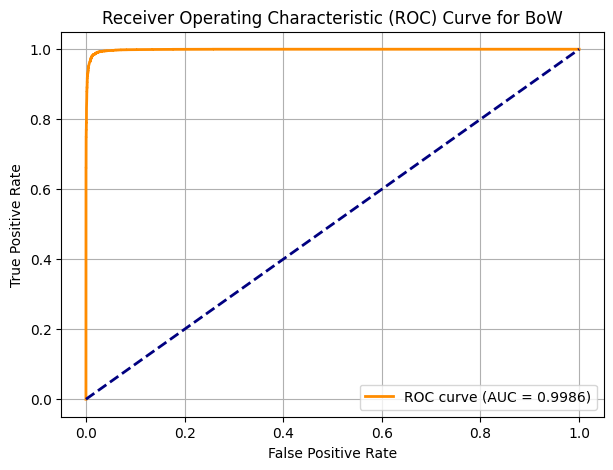

In [11]:
# Predict probabilities
y_probs = clf.predict_proba(X_test)[:, 1]

# ROC calculation
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for BoW')
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [12]:
# Vectorization text using TF-IDF
TF_IDF = TfidfVectorizer(stop_words='english', max_df=0.7)
X_TF_IDF = TF_IDF.fit_transform(X)

# split train & test dataset
X_train, X_test, y_train, y_test = train_test_split(X_TF_IDF, y, test_size=0.2, random_state=42)
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)


In [13]:
# Train LGBM
clf = lgb.LGBMClassifier(verbose=-1)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9884    0.9738    0.9810      7935
           1     0.9760    0.9894    0.9827      8563

    accuracy                         0.9819     16498
   macro avg     0.9822    0.9816    0.9818     16498
weighted avg     0.9820    0.9819    0.9819     16498



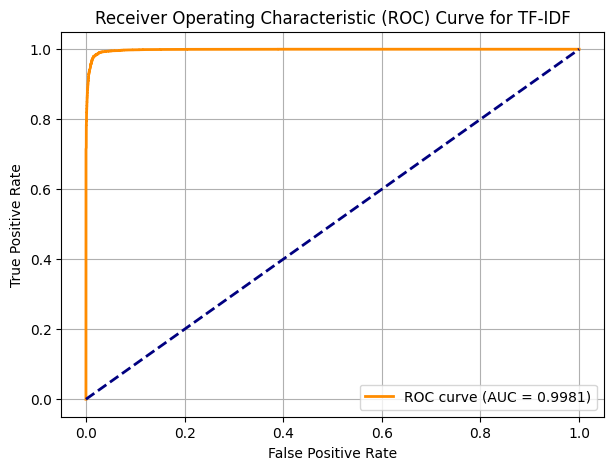

In [14]:
# Predict probabilities
y_probs = clf.predict_proba(X_test)[:, 1]

# ROC calculation
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for TF-IDF')
plt.legend(loc="lower right")
plt.grid()
plt.show()

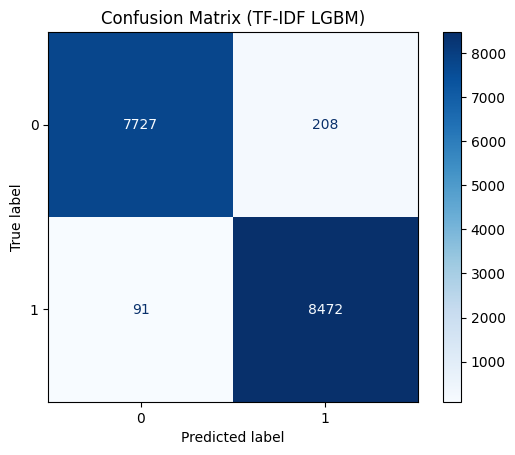

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix (TF-IDF LGBM)")
plt.show()

# Deal with missing/duplicate data